In [26]:
from urllib.request import urlopen
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

url = "https://i.redd.it/2ax9q1v1ssqg1.png"

img = Image.open(urlopen(url))
img_array = np.array(img)
print(img.info.get('dpi'))

None


Text(0.5, 1.0, 'Gambar Asli')

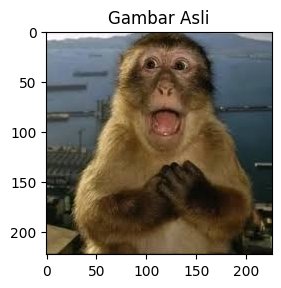

In [31]:
plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Gambar Asli")

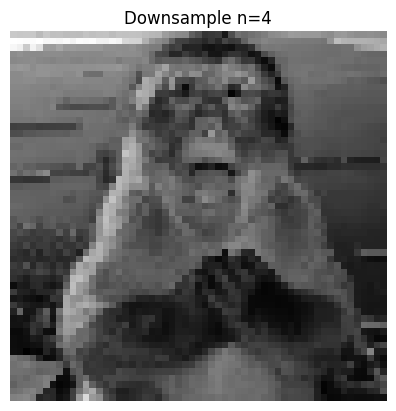

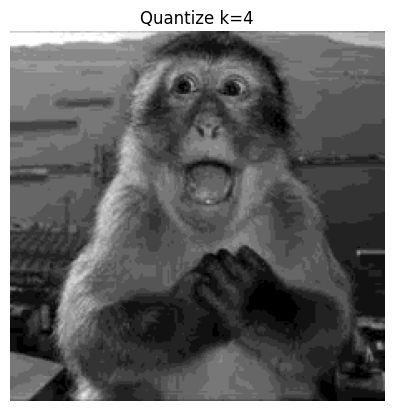

Dimensi fisik: 0.75 x 0.74 inci
Ukuran memori: 49.22 KB


In [33]:
# load gambar contoh, grayscale
img = Image.open(urlopen(url)).convert("L")
img_array = np.array(img)

# test 1: image sampling
img_kecil = downsample(img_array, 4)
plt.imshow(img_kecil, cmap='gray')
plt.title("Downsample n=4")
plt.axis('off')
plt.show()

# test 2: image quantization
hasil_quant = quantize(img_array, 4)
plt.imshow(hasil_quant, cmap='gray')
plt.title("Quantize k=4")
plt.axis('off')
plt.show()

# test 3: image properties
width_in, height_in, size_kb = image_properties(img_array, dpi=300)
print(f"Dimensi fisik: {width_in:.2f} x {height_in:.2f} inci")
print(f"Ukuran memori: {size_kb:.2f} KB")

In [28]:
def downsample(image, n):
    return image[::n, ::n]

Text(0.5, 1.0, 'Gambar Asli')

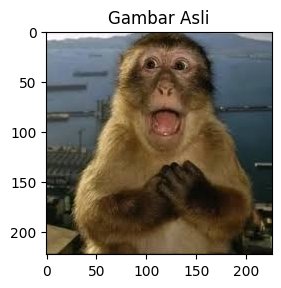

In [27]:
img_kecil = downsample(img_array, 4)

plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Gambar Asli")

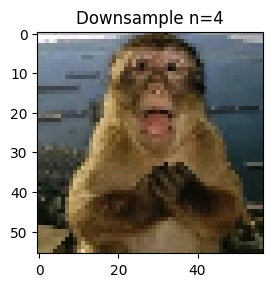

In [22]:
plt.subplot(1, 2, 2)
plt.imshow(img_kecil)
plt.title("Downsample n=4")
plt.show()

(223, 226)


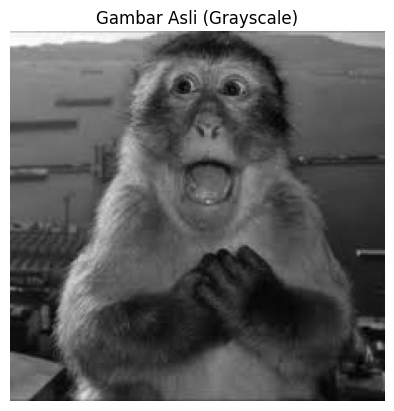

In [23]:
img = Image.open(urlopen(url)).convert("L") # "L" = convert ke grayscale
img_array = np.array(img)

print(img_array.shape) # (tinggi, lebar), tanpa channel warna

plt.imshow(img_array, cmap='gray') # harus pake cmap='gray', karenat default dari matplotlib akan otomatis memberikan warna pake colormap default
plt.title("Gambar Asli (Grayscale)")
plt.axis('off')
plt.show()

In [24]:
def quantize(image, k):
    levels = 2 ** k
    step = 256 // levels
    indices = image.astype(np.int32) // step
    indices = np.clip(indices, 0, levels - 1)
    scaled = (indices * 255 // (levels - 1)).astype(np.uint8)
    return scaled

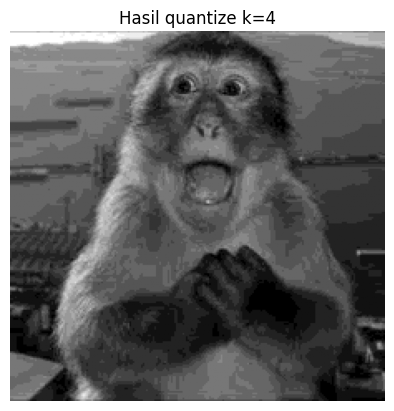

In [25]:
hasil = quantize(img_array, 4)
plt.imshow(hasil, cmap = 'gray')
plt.title("Hasil quantize k=4")
plt.axis('off')
plt.show()

In [29]:
def image_properties(image, dpi, bit_depth=8):
    if image.ndim == 3:
        height_px, width_px, channels = image.shape
    else:
        height_px, width_px = image.shape
        channels = 1

    width_in = width_px / dpi
    height_in = height_px / dpi

    total_bits = width_px * height_px * channels * bit_depth
    size_kb = (total_bits / 8) / 1024

    return width_in, height_in, size_kb

In [30]:
width_in, height_in, size_kb = image_properties(img_array, dpi=300)

print(f"Dimensi fisik: {width_in:.2f} x {height_in:.2f} inci")
print(f"Ukuran memori (uncompressed): {size_kb:.2f} KB")

Dimensi fisik: 0.75 x 0.74 inci
Ukuran memori (uncompressed): 147.65 KB
